# Tasks for laboratory assignment 3

In [9]:
# imports section

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier


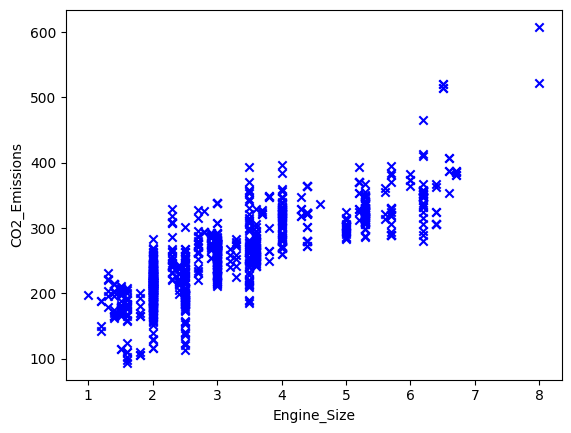

In [10]:
def build_plot(file_path, x, y):
    data = pd.read_csv(file_path)
    plt.scatter(data[x], data[y], c='blue', marker='x')
    plt.xlabel(x)
    plt.ylabel(y)
    return plt

build_plot('resources/CO2_emission.csv', 'Engine_Size', 'CO2_Emissions').show()


In [11]:
def extract_texts_from_file(file_path):
    """
    Extract the text data from the csv file

    Args:
        file_path (str): Relative location of the csv file in the project.

    Returns:
        list: The list of texts as strings.
    """
    df = pd.read_csv(file_path)
    return df.to_dict('records')

data = extract_texts_from_file('resources/heart.csv')
print(data[:50])

[{'age': 63, 'sex': 1, 'cp': 3, 'trtbps': 145, 'chol': 233, 'fbs': 1, 'restecg': 0, 'thalachh': 150, 'exng': 0, 'oldpeak': 2.3, 'slp': 0, 'caa': 0, 'thall': 1, 'output': 1}, {'age': 37, 'sex': 1, 'cp': 2, 'trtbps': 130, 'chol': 250, 'fbs': 0, 'restecg': 1, 'thalachh': 187, 'exng': 0, 'oldpeak': 3.5, 'slp': 0, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 41, 'sex': 0, 'cp': 1, 'trtbps': 130, 'chol': 204, 'fbs': 0, 'restecg': 0, 'thalachh': 172, 'exng': 0, 'oldpeak': 1.4, 'slp': 2, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 56, 'sex': 1, 'cp': 1, 'trtbps': 120, 'chol': 236, 'fbs': 0, 'restecg': 1, 'thalachh': 178, 'exng': 0, 'oldpeak': 0.8, 'slp': 2, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 57, 'sex': 0, 'cp': 0, 'trtbps': 120, 'chol': 354, 'fbs': 0, 'restecg': 1, 'thalachh': 163, 'exng': 1, 'oldpeak': 0.6, 'slp': 2, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 57, 'sex': 1, 'cp': 0, 'trtbps': 140, 'chol': 192, 'fbs': 0, 'restecg': 1, 'thalachh': 148, 'exng': 0, 'oldpeak': 0.4, 'slp': 

## CO2 emissions

Process file `CO2_emission.csv`. Build a model, that would predict CO2 emissions from the size of the engine of car. Visualize model on a plot.

Choose regression model that would best fit the data. Choose the library for model implementation (sklearn, other library, custom implementation).

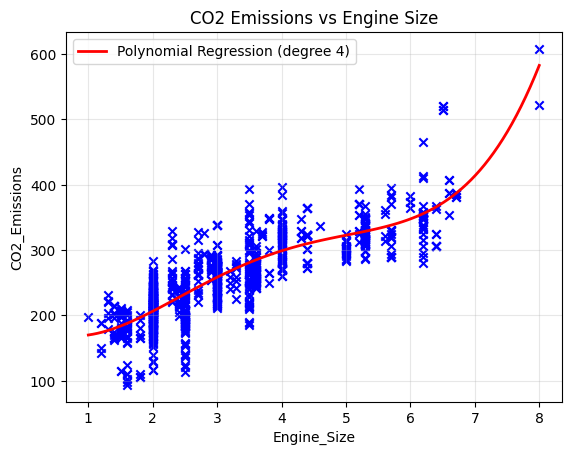

[198.97238447802283,
 0.0,
 -83.53403051636673,
 67.6487431172746,
 -13.857801595517955,
 0.9320101257867037]

In [12]:
def CO2_emissions(data):
    """
    Build a model that would predict CO2 emissions from the size of the engine of car. Visualize model on a plot.

    Args:
        data: CO2 emissions data.

    Returns:
        list: The list of model theta parameters.
    """
    df = pd.DataFrame(data)
    
    X = df[['Engine_Size']].values
    y = df['CO2_Emissions'].values
    
    # polynomial regression model (degree 4) - best fitting model
    # polynomial regression of degree 4 shows R**2=0.7098 vs degree 3 R**2=0.6991 vs Linear R**2=0.6818
    poly_features = PolynomialFeatures(degree=4)
    X_poly = poly_features.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    
    X_pred = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_pred_poly = poly_features.transform(X_pred)
    y_pred = model.predict(X_pred_poly)
    
    plot = build_plot('resources/CO2_emission.csv', 'Engine_Size', 'CO2_Emissions')
    
    plot.plot(X_pred, y_pred, 'r-', linewidth=2, label='Polynomial Regression (degree 4)')
    plot.legend()
    plot.title('CO2 Emissions vs Engine Size')
    plot.grid(True, alpha=0.3)
    plot.show()
    
    return [model.intercept_] + model.coef_.tolist()

data = extract_texts_from_file('resources/CO2_emission.csv')
CO2_emissions(data)

## Ice Cream Sales

Process file `ice_cream_selling_data.csv`. Build a model, that would predict ice cream sales based on the temperature. Visualize model on a plot.

Choose regression model that would best fit the data. Choose the library for model implementation (sklearn, other library, custom implementation).

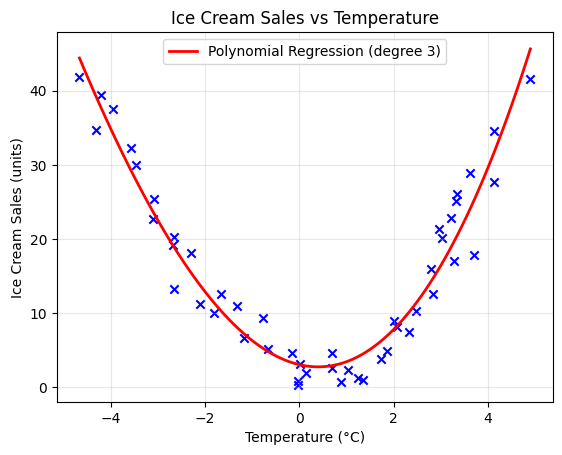

[3.061373017339159,
 0.0,
 -1.4809035312338636,
 1.824312099540442,
 0.05141274165992993]

In [13]:
def ice_cream_selling(data):
    """
    Build a model, that would predict ice cream sales based on the temperature. Visualize model on a plot.

    Args:
        data: ice cream sales data.

    Returns:
        list: The list of model theta parameters.
    """
    df = pd.DataFrame(data)
    
    temp_col = df.columns[0]  
    sales_col = df.columns[1]  
    
    X = df[[temp_col]].values
    y = df[sales_col].values
    
    # polynomial regression model (degree 3) - best fitting model
    # polynomial regression of degree 3 shows R2=0.9367 vs Linear R2=0.0307 vs Polynomial degree 2 R2=0.9321
    poly_features = PolynomialFeatures(degree=3)
    X_poly = poly_features.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    
    X_pred = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_pred_poly = poly_features.transform(X_pred)
    y_pred = model.predict(X_pred_poly)
    
    plot = build_plot('resources/ice_cream_selling_data.csv', temp_col, sales_col)
    
    plot.plot(X_pred, y_pred, 'r-', linewidth=2, label='Polynomial Regression (degree 3)')
    plot.legend()
    plot.title('Ice Cream Sales vs Temperature')
    plot.grid(True, alpha=0.3)
    plot.show()
    
    return [model.intercept_] + model.coef_.tolist()

data = extract_texts_from_file('resources/ice_cream_selling_data.csv')
ice_cream_selling(data)

## Electric Power Consumption

Process file `powerconsumption.csv`. Build a model, that would predict electricity consumption from the weather: temperature, humidity and wind speed. Visualize model on a plot.

Choose regression model that would best fit the data. Choose the library for model implementation (sklearn, other library, custom implementation).

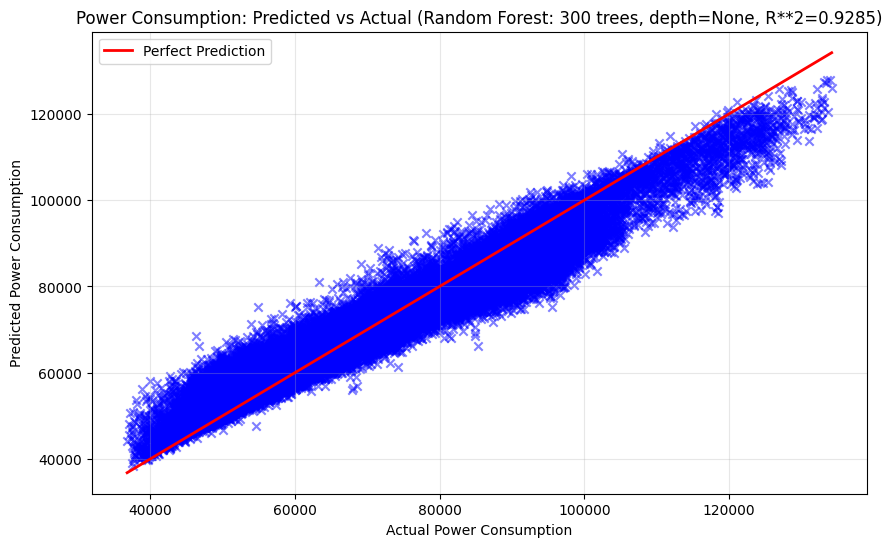

[0.5124618021051082, 0.31479275933432566, 0.17274543856056618]

In [14]:
def power_consumption(data):
    """
    Build a model, that would predict electricity consumption from the weather: temperature, humidity and wind speed. 
    Visualize model on a plot.

    Args:
        data: power consumption data.

    Returns:
        list: The list of model theta parameters.
    """
    df = pd.DataFrame(data)

    X = df[['Temperature', 'Humidity', 'WindSpeed']].values
    y = df['PowerConsumption_Zone1'].values + df['PowerConsumption_Zone2'].values + df['PowerConsumption_Zone3'].values
    
    # Random Forest Regressor (300 trees, depth=None) - best fitting model
    # Random Forest shows best performance with R**2=0.9285 vs RF (200 trees, depth=20, min_split=5) R**2=0.7975 
    # vs RF (200 trees, depth=15) R**2=0.6950 vs Polynomial degree 4 R**2=0.3160 vs Linear R**2=0.2454
    model = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
    model.fit(X, y)
    
    y_pred = model.predict(X)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(y, y_pred, alpha=0.5, c='blue', marker='x')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r-', linewidth=2, label='Perfect Prediction')
    plt.xlabel('Actual Power Consumption')
    plt.ylabel('Predicted Power Consumption')
    plt.title('Power Consumption: Predicted vs Actual (Random Forest: 300 trees, depth=None, R**2=0.9285)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    feature_importances = model.feature_importances_.tolist()
    return feature_importances

data = extract_texts_from_file('resources/powerconsumption.csv')
power_consumption(data)

## Heart Conditions Predictions

Process file `heart.csv`. It has the following data:

- age - Age of the patient
- sex - Sex of the patient
- cp - Chest pain type ~ 0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic
- trtbps - Resting blood pressure (in mm Hg)
- chol - Cholestoral in mg/dl fetched via BMI sensor
- fbs - (fasting blood sugar > 120 mg/dl) ~ 1 = True, 0 = False
- restecg - Resting electrocardiographic results ~ 0 = Normal, 1 = ST-T wave normality, 2 = Left ventricular hypertrophy
- thalachh - Maximum heart rate achieved
- oldpeak - Previous peak
- slp - Slope
- caa - Number of major vessels
- thall - Thalium Stress Test result ~ (0,3)
- exng - Exercise induced angina ~ 1 = Yes, 0 = No
- output - Target variable - risk of heart attack - 1 is high chance of heart attack and 0 is low chance.

Use classification model (choose model best fitting model yourself). Choose parameters that would best fit for making a prediction on. Visualize model on a plot.

*Bonus points*: split data into train data and validation data. Validate your model.

Validation Accuracy: 0.8852

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.89      0.86      0.88        29
   High Risk       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



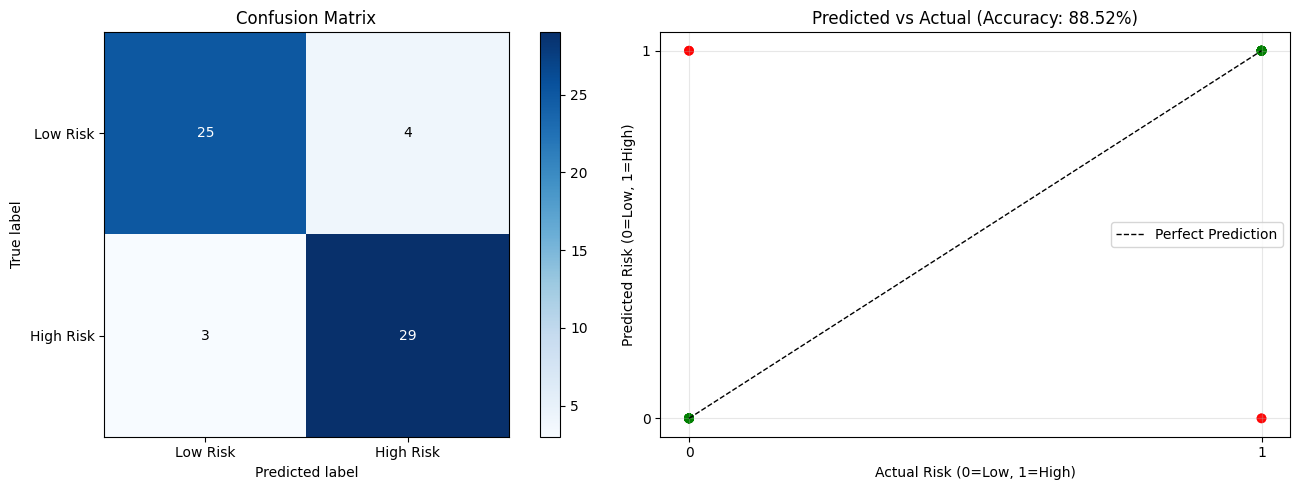

[0.822509502010383,
 -0.004422483462127006,
 -0.6351379788854759,
 0.5759780196171583,
 -0.012762391519502888,
 -0.0016485298937859918,
 0.03074367367816954,
 0.2003214977666056,
 0.021723808334587487,
 -0.46480691262112944,
 -0.5242706978323826,
 0.33626687349494994,
 -0.5450747154787106,
 -0.5631846842934973]

In [15]:
def heart_classification(data):
    """
    Build a model, that would classify risk category for heart attack. 
    Visualize model on a plot.

    Args:
        data: heart medical data.

    Returns:
        list: The list of model theta parameters.
    """
    df = pd.DataFrame(data)
    
    X = df.drop('output', axis=1).values
    y = df['output'].values
    
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Build LogisticRegression model with best parameters
    # Best parameters: C=0.1, solver='lbfgs' (accuracy: 0.8852)
    # LogisticRegression shows best performance compared to RidgeClassifier (0.8689) and SGDClassifier (0.4918)
    model = LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    
    accuracy = accuracy_score(y_val, y_pred)
    print(f'Validation Accuracy: {accuracy:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_val, y_pred, target_names=['Low Risk', 'High Risk']))
    
    cm = confusion_matrix(y_val, y_pred)
    
    _, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    im = axes[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[0].figure.colorbar(im, ax=axes[0])
    axes[0].set(xticks=np.arange(cm.shape[1]),
                yticks=np.arange(cm.shape[0]),
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'],
                title='Confusion Matrix',
                ylabel='True label',
                xlabel='Predicted label')
    
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(j, i, format(cm[i, j], 'd'),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black")
    
    axes[1].scatter(y_val, y_pred, alpha=0.6, c=['red' if y_val[i] != y_pred[i] else 'green' for i in range(len(y_val))])
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect Prediction')
    axes[1].set_xlabel('Actual Risk (0=Low, 1=High)')
    axes[1].set_ylabel('Predicted Risk (0=Low, 1=High)')
    axes[1].set_title(f'Predicted vs Actual (Accuracy: {accuracy:.2%})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks([0, 1])
    axes[1].set_yticks([0, 1])
    
    plt.tight_layout()
    plt.show()
    
    return [model.intercept_[0]] + model.coef_[0].tolist()

data = extract_texts_from_file('resources/heart.csv')
heart_classification(data)

## Additional (extra credit)

There are more files in the `resources` folder. Take a look at the. Visualize data in these files. Choose ML algorithm for building a model and making predictions for new data. Visualize the model.

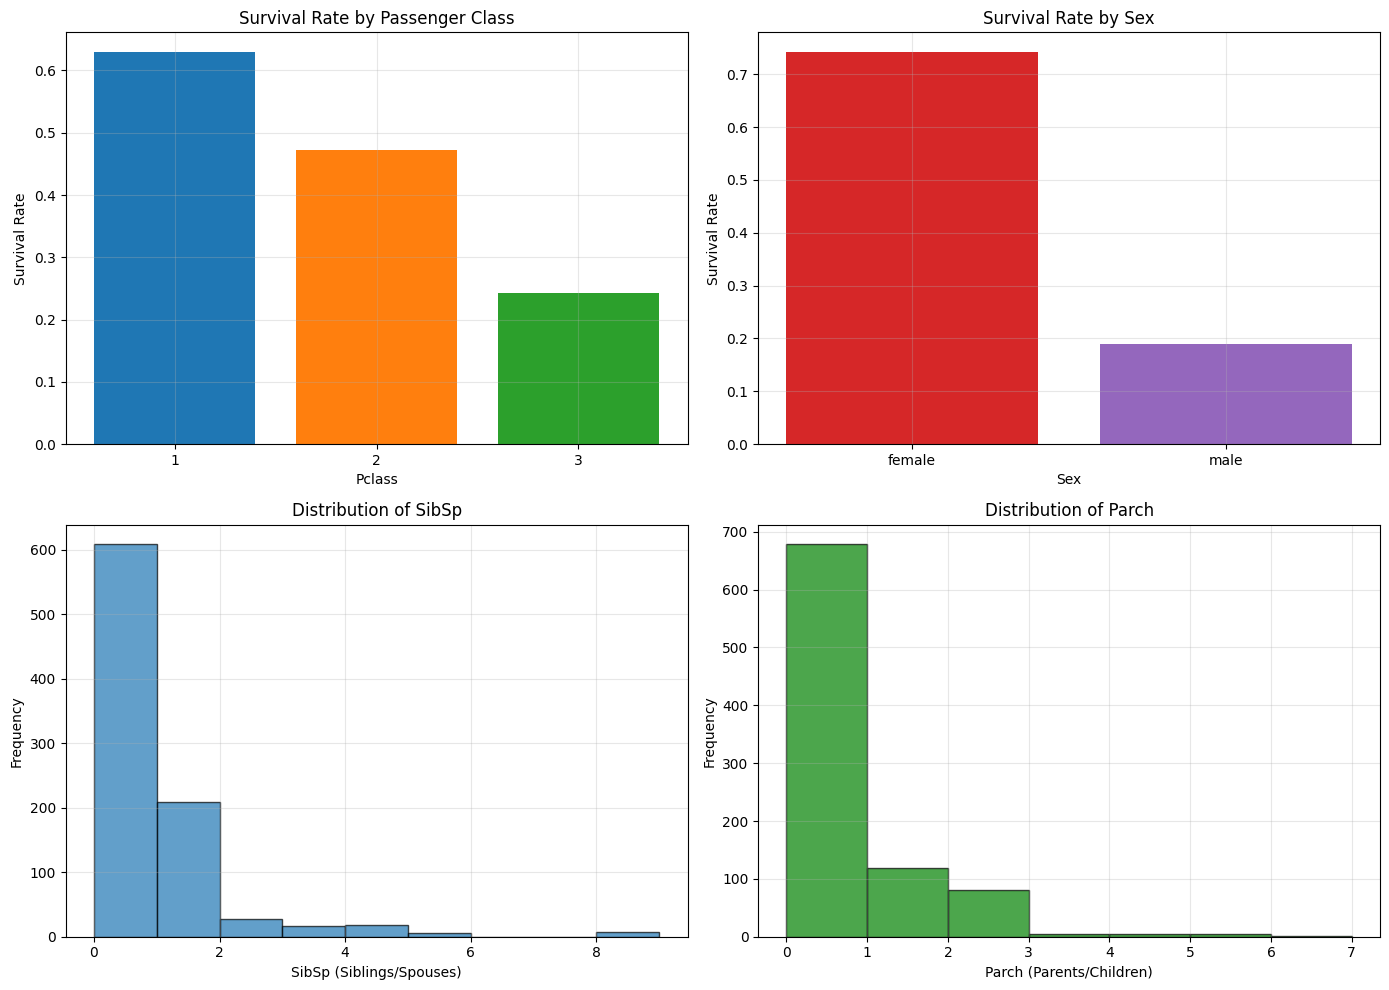

Random Forest Model Metrics:
Accuracy:  0.9019
Precision: 0.8936
Recall:    0.8289
F1-Score:  0.8601

Gradient Boosting Model Metrics:
Accuracy:  0.9713
Precision: 0.9795
Recall:    0.9408
F1-Score:  0.9597


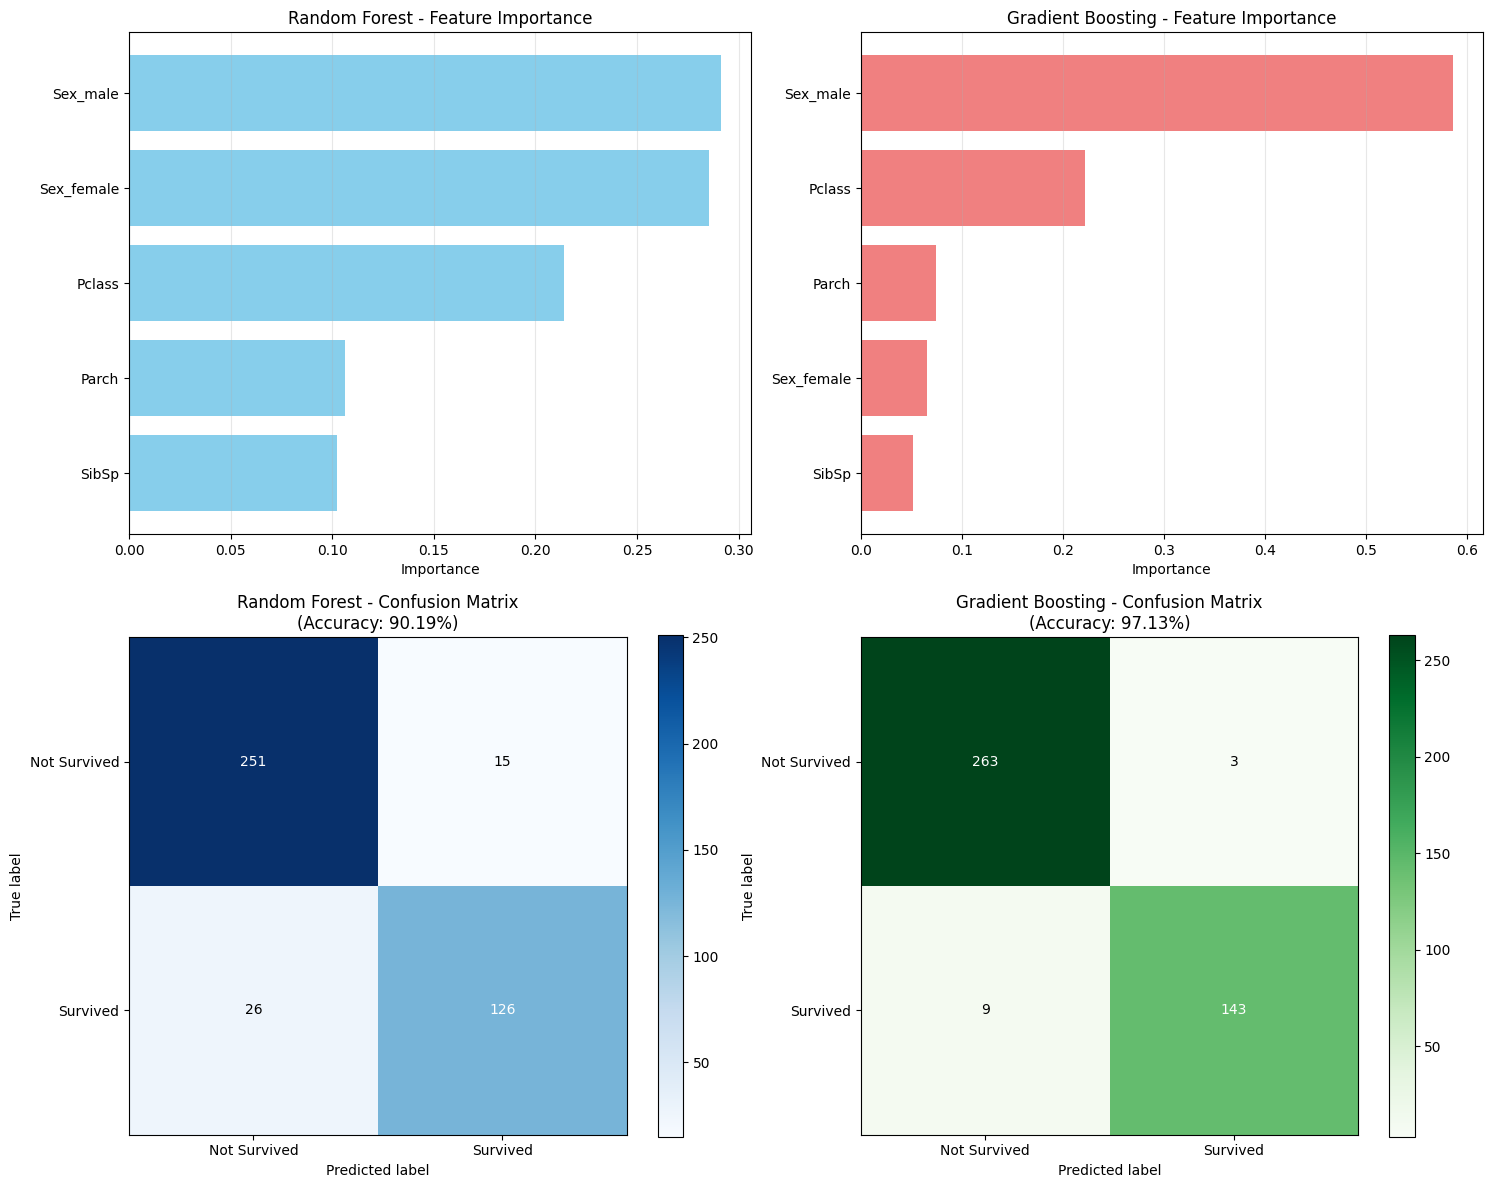

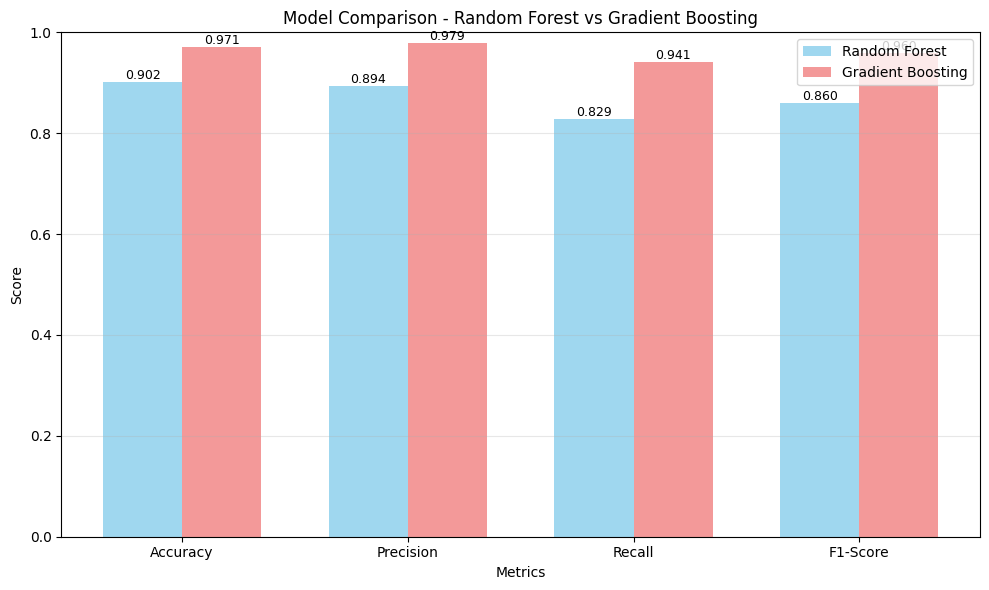


Predictions saved to:
  - results/submission_rf.csv
  - results/submission_gb.csv


In [16]:
import pandas as pd 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import os

train_data = pd.read_csv("./resources/titanic/train.csv")
test_data = pd.read_csv("./resources/titanic/test.csv")
test_answers = pd.read_csv("./resources/titanic/gender_submission.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

survival_by_class = train_data.groupby('Pclass')['Survived'].mean()
axes[0, 0].bar(survival_by_class.index, survival_by_class.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 0].set_xlabel('Pclass')
axes[0, 0].set_ylabel('Survival Rate')
axes[0, 0].set_title('Survival Rate by Passenger Class')
axes[0, 0].set_xticks([1, 2, 3])
axes[0, 0].grid(True, alpha=0.3)

survival_by_sex = train_data.groupby('Sex')['Survived'].mean()
axes[0, 1].bar(survival_by_sex.index, survival_by_sex.values, color=['#d62728', '#9467bd'])
axes[0, 1].set_xlabel('Sex')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].set_title('Survival Rate by Sex')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(train_data['SibSp'], bins=range(train_data['SibSp'].max()+2), edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('SibSp (Siblings/Spouses)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of SibSp')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(train_data['Parch'], bins=range(train_data['Parch'].max()+2), edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Parch (Parents/Children)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Parch')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

features = ["Pclass", "Sex", "SibSp", "Parch"]
y = train_data["Survived"]

X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])
y_test = test_answers["Survived"]

X_test = X_test.reindex(columns=X.columns, fill_value=0)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)
rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Model Metrics:")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X, y)
gb_predictions = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_predictions)
gb_precision = precision_score(y_test, gb_predictions)
gb_recall = recall_score(y_test, gb_predictions)
gb_f1 = f1_score(y_test, gb_predictions)

print("\nGradient Boosting Model Metrics:")
print(f"Accuracy:  {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall:    {gb_recall:.4f}")
print(f"F1-Score:  {gb_f1:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
axes[0, 0].barh(rf_importance.index, rf_importance.values, color='skyblue')
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title('Random Forest - Feature Importance')
axes[0, 0].grid(True, alpha=0.3, axis='x')

gb_importance = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=True)
axes[0, 1].barh(gb_importance.index, gb_importance.values, color='lightcoral')
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title('Gradient Boosting - Feature Importance')
axes[0, 1].grid(True, alpha=0.3, axis='x')

rf_cm = confusion_matrix(y_test, rf_predictions)
im1 = axes[1, 0].imshow(rf_cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[1, 0].figure.colorbar(im1, ax=axes[1, 0])
axes[1, 0].set(xticks=np.arange(rf_cm.shape[1]),
                yticks=np.arange(rf_cm.shape[0]),
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'],
                title=f'Random Forest - Confusion Matrix\n(Accuracy: {rf_accuracy:.2%})',
                ylabel='True label',
                xlabel='Predicted label')
thresh = rf_cm.max() / 2.
for i in range(rf_cm.shape[0]):
    for j in range(rf_cm.shape[1]):
        axes[1, 0].text(j, i, format(rf_cm[i, j], 'd'),
                       ha="center", va="center",
                       color="white" if rf_cm[i, j] > thresh else "black")

gb_cm = confusion_matrix(y_test, gb_predictions)
im2 = axes[1, 1].imshow(gb_cm, interpolation='nearest', cmap=plt.cm.Greens)
axes[1, 1].figure.colorbar(im2, ax=axes[1, 1])
axes[1, 1].set(xticks=np.arange(gb_cm.shape[1]),
                yticks=np.arange(gb_cm.shape[0]),
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'],
                title=f'Gradient Boosting - Confusion Matrix\n(Accuracy: {gb_accuracy:.2%})',
                ylabel='True label',
                xlabel='Predicted label')
thresh = gb_cm.max() / 2.
for i in range(gb_cm.shape[0]):
    for j in range(gb_cm.shape[1]):
        axes[1, 1].text(j, i, format(gb_cm[i, j], 'd'),
                       ha="center", va="center",
                       color="white" if gb_cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
models = ['Random Forest', 'Gradient Boosting']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_metrics = [rf_accuracy, rf_precision, rf_recall, rf_f1]
gb_metrics = [gb_accuracy, gb_precision, gb_recall, gb_f1]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, rf_metrics, width, label='Random Forest', color='skyblue', alpha=0.8)
bars2 = ax.bar(x + width/2, gb_metrics, width, label='Gradient Boosting', color='lightcoral', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Comparison - Random Forest vs Gradient Boosting')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}',
               ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

os.makedirs('results', exist_ok=True)
rf_output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': rf_predictions})
rf_output.to_csv('results/submission_rf.csv', index=False)

gb_output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': gb_predictions})
gb_output.to_csv('results/submission_gb.csv', index=False)

print("\nPredictions saved to:")
print("  - results/submission_rf.csv")
print("  - results/submission_gb.csv")
